# Demo ANN tự xây bằng NumPy

Notebook này phân loại hoa Iris bằng một mạng neural network tự viết. `scikit-learn` chỉ cung cấp dataset qua `load_iris`; model không dùng `MLPClassifier` hay pipeline có sẵn.

Kiến trúc mạng:

```text
4 input features -> 8 hidden neurons with a selectable activation -> 3 output neurons with softmax
```

Mỗi mẫu có bốn số đo: sepal length, sepal width, petal length và petal width. Output là một trong ba loài `setosa`, `versicolor` hoặc `virginica`.

Luồng xử lý của một batch:

```text
raw input (n, 4)
    -> chuẩn hóa
hidden pre-activation (n, 8) = input @ W1 + b1
    -> hidden activation (tanh, sigmoid, ReLU, ...)
hidden output (n, 8)
    -> input @ W2 + b2
output logits (n, 3)
    -> softmax
output probabilities (n, 3)
```

In [24]:
# NumPy xử lý mảng, phép nhân ma trận và gradient update thủ công.
import numpy as np

# Matplotlib dùng để vẽ loss curve, activation và confusion matrix.
import matplotlib.pyplot as plt

# scikit-learn chỉ cung cấp dữ liệu Iris, không cung cấp model ANN.
from sklearn.datasets import load_iris

np.set_printoptions(precision=3, suppress=True)

## 1. Chuẩn bị dữ liệu

Ta chia từng loài theo tỉ lệ 60/20/20 cho training, validation và test. Validation dùng để theo dõi model trong lúc train; test chỉ dùng ở bước đánh giá cuối. Mean và standard deviation chỉ lấy từ training set, sau đó dùng lại cho validation và test.

- Training set: tạo loss và gradient để học weights.
- Validation set: đo sau mỗi epoch, không tạo gradient update.
- Test set: chỉ mở ở cuối để báo cáo kết quả trên dữ liệu chưa dùng trước đó.

In [25]:
# Dataset có 150 mẫu hoa, mỗi mẫu có bốn feature đo được.
# feature_matrix có shape (150, 4), còn target_labels có shape (150,).
# Mỗi target là class ID: 0 = setosa, 1 = versicolor, 2 = virginica.
iris_dataset = load_iris()
feature_matrix = iris_dataset.data
target_labels = iris_dataset.target

# Dùng random generator riêng để lần chạy lại có cùng cách chia dữ liệu.
# random seed không làm model tốt hơn; nó chỉ giúp kết quả tái lập được.
random_generator = np.random.default_rng(42)
training_indices_by_class = []
validation_indices_by_class = []
testing_indices_by_class = []

# Giữ 60% train, 20% validation và 20% test của mỗi lớp.
# Chia theo từng lớp giúp cả ba tập đều có đủ ba loài hoa.
for class_label in np.unique(target_labels):
    class_indices = np.flatnonzero(target_labels == class_label)
    random_generator.shuffle(class_indices)
    training_sample_count = int(0.60 * len(class_indices))
    validation_sample_count = int(0.20 * len(class_indices))
    training_indices_by_class.append(class_indices[:training_sample_count])
    validation_indices_by_class.append(
        class_indices[training_sample_count:training_sample_count + validation_sample_count]
    )
    testing_indices_by_class.append(
        class_indices[training_sample_count + validation_sample_count:]
    )

training_indices = np.concatenate(training_indices_by_class)
validation_indices = np.concatenate(validation_indices_by_class)
testing_indices = np.concatenate(testing_indices_by_class)
random_generator.shuffle(training_indices)
random_generator.shuffle(validation_indices)
random_generator.shuffle(testing_indices)

# Giữ dữ liệu gốc để hiển thị input dễ hiểu trong phần trace.
training_features_raw = feature_matrix[training_indices]
training_labels = target_labels[training_indices]
validation_features_raw = feature_matrix[validation_indices]
validation_labels = target_labels[validation_indices]
testing_features_raw = feature_matrix[testing_indices]
testing_labels = target_labels[testing_indices]

# Chỉ dùng training set để tính thông số chuẩn hóa.
# Nếu lấy mean/std từ validation hoặc test, thông tin từ dữ liệu đánh giá
# sẽ bị rò rỉ vào quá trình chuẩn bị model.
training_feature_means = training_features_raw.mean(axis=0)
training_feature_stds = training_features_raw.std(axis=0)
# Chuẩn hóa để các feature có thang đo gần nhau, giúp gradient ổn định hơn.
training_features = (training_features_raw - training_feature_means) / training_feature_stds
# Validation và test dùng lại mean/std của training, không tự tính lại.
validation_features = (validation_features_raw - training_feature_means) / training_feature_stds
testing_features = (testing_features_raw - training_feature_means) / training_feature_stds

print('Training features:', training_features.shape)
print('Validation features:', validation_features.shape)
print('Testing features:', testing_features.shape)
print('Class names:', iris_dataset.target_names)

Training features: (90, 4)
Validation features: (30, 4)
Testing features: (30, 4)
Class names: ['setosa' 'versicolor' 'virginica']


In [26]:
# Đổi class ID thành dạng one-hot, ví dụ setosa -> [1, 0, 0].
# One-hot phù hợp với output gồm ba xác suất của softmax.
def one_hot_encode(class_labels, number_of_classes):
    # Tạo ma trận toàn số 0: mỗi hàng tương ứng một mẫu.
    encoded_labels = np.zeros((class_labels.size, number_of_classes))
    # Chọn đúng một vị trí trong mỗi hàng và đặt thành 1.
    encoded_labels[np.arange(class_labels.size), class_labels] = 1
    return encoded_labels

training_one_hot_labels = one_hot_encode(training_labels, number_of_classes=3)
validation_one_hot_labels = one_hot_encode(validation_labels, number_of_classes=3)
print('Training one-hot labels:', training_one_hot_labels.shape)
print('Validation one-hot labels:', validation_one_hot_labels.shape)

Training one-hot labels: (90, 3)
Validation one-hot labels: (30, 3)


## 2. Tự xây ANN

`SimpleANN` có hai lớp chứa weights và bias:

- `input_to_hidden_weights`: shape `(4, 8)`
- `hidden_to_output_weights`: shape `(8, 3)`
- hidden activation mặc định: `tanh` (có thể thay bằng các activation trong phần so sánh)
- output activation: `softmax`

Input layer không có weights riêng. Nó chỉ nhận bốn feature đã chuẩn hóa.

| Thành phần | Input shape | Output shape | Phép tính |
|---|---:|---:|---|
| Input layer | `(n, 4)` | `(n, 4)` | nhận feature |
| Hidden layer | `(n, 4)` | `(n, 8)` | `activation(X @ W1 + b1)` |
| Output layer | `(n, 8)` | `(n, 3)` | `softmax(H @ W2 + b2)` |

Trong đó `n` là số mẫu của batch. `W1` có shape `(4, 8)`, `W2` có shape `(8, 3)`.

In [27]:
# Softmax biến ba logits thành ba xác suất có tổng bằng 1.
# Ví dụ logits [2, 1, 0] sẽ thành các xác suất cho ba loài hoa.
# Dịch logits trước khi exp để softmax ổn định hơn với giá trị lớn.
def softmax(logits):
    # Trừ giá trị lớn nhất không làm thay đổi kết quả softmax,
    # nhưng tránh exp() tạo ra số quá lớn gây overflow.
    shifted_logits = logits - logits.max(axis=1, keepdims=True)
    exponentiated_logits = np.exp(shifted_logits)
    # Chia cho tổng exp để mỗi hàng trở thành một phân phối xác suất.
    return exponentiated_logits / exponentiated_logits.sum(axis=1, keepdims=True)


# Các activation dưới đây được áp dụng cho hidden layer.
# Output layer vẫn dùng softmax vì đây là bài toán phân loại ba lớp.
SUPPORTED_ACTIVATION_NAMES = (
    'tanh',
    'sigmoid',
    'relu',
    'leaky_relu',
    'softplus',
    'identity',
)


def apply_hidden_activation(pre_activation_values, activation_name):
    """Tính output của hidden layer theo activation được chọn."""
    if activation_name == 'tanh':
        return np.tanh(pre_activation_values)
    if activation_name == 'sigmoid':
        # Clip để exp không overflow khi input có trị tuyệt đối quá lớn.
        clipped_values = np.clip(pre_activation_values, -500, 500)
        return 1 / (1 + np.exp(-clipped_values))
    if activation_name == 'relu':
        return np.maximum(0, pre_activation_values)
    if activation_name == 'leaky_relu':
        return np.where(pre_activation_values > 0, pre_activation_values, 0.01 * pre_activation_values)
    if activation_name == 'softplus':
        # logaddexp ổn định số hơn công thức log(1 + exp(x)) trực tiếp.
        return np.logaddexp(0, pre_activation_values)
    if activation_name == 'identity':
        return pre_activation_values
    raise ValueError(
        f'Unknown activation {activation_name!r}. '
        f'Choose one of {SUPPORTED_ACTIVATION_NAMES}.'
    )


def hidden_activation_derivative(pre_activation_values, activation_name):
    """Tính đạo hàm để backpropagation đi qua hidden activation."""
    if activation_name == 'tanh':
        hidden_output_values = np.tanh(pre_activation_values)
        return 1 - hidden_output_values ** 2
    if activation_name == 'sigmoid':
        sigmoid_values = apply_hidden_activation(pre_activation_values, 'sigmoid')
        return sigmoid_values * (1 - sigmoid_values)
    if activation_name == 'relu':
        return (pre_activation_values > 0).astype(float)
    if activation_name == 'leaky_relu':
        return np.where(pre_activation_values > 0, 1.0, 0.01)
    if activation_name == 'softplus':
        return apply_hidden_activation(pre_activation_values, 'sigmoid')
    if activation_name == 'identity':
        return np.ones_like(pre_activation_values)
    raise ValueError(
        f'Unknown activation {activation_name!r}. '
        f'Choose one of {SUPPORTED_ACTIVATION_NAMES}.'
    )


# Mạng có cấu trúc 4 -> 8 -> 3.
class SimpleANN:
    def __init__(
        self,
        input_feature_count=4,
        hidden_neuron_count=8,
        output_class_count=3,
        learning_rate=0.05,
        random_seed=42,
        hidden_activation_name='tanh',
    ):
        # Activation chỉ thay đổi hidden layer; softmax vẫn giữ ở output.
        if hidden_activation_name not in SUPPORTED_ACTIVATION_NAMES:
            raise ValueError(
                f'Choose hidden activation from {SUPPORTED_ACTIVATION_NAMES}.'
            )
        self.hidden_activation_name = hidden_activation_name
        # Đây là các tham số model sẽ học trong quá trình training.
        # W_input_hidden có shape (4, 8): mỗi input nối tới mỗi hidden neuron.
        random_generator = np.random.default_rng(random_seed)
        self.input_to_hidden_weights = random_generator.normal(
            0, 0.5, size=(input_feature_count, hidden_neuron_count)
        )
        # Bias hidden có shape (1, 8), được broadcast cho mọi mẫu trong batch.
        self.hidden_layer_biases = np.zeros((1, hidden_neuron_count))
        self.hidden_to_output_weights = random_generator.normal(
            0, 0.5, size=(hidden_neuron_count, output_class_count)
        )
        # Bias output có shape (1, 3), một bias cho mỗi loài hoa.
        self.output_layer_biases = np.zeros((1, output_class_count))
        self.learning_rate = learning_rate
        self.loss_history = []
        self.validation_loss_history = []
        self.validation_accuracy_history = []

    def forward(self, input_features):
        # Hidden layer: bốn input thành tám giá trị trung gian.
        # (batch_size, 4) @ (4, 8) = (batch_size, 8).
        hidden_layer_pre_activation = (
            input_features @ self.input_to_hidden_weights
            + self.hidden_layer_biases
        )
        # Activation biến đổi hidden pre-activation thành biểu diễn trung gian.
        # Model chính dùng tanh; các model so sánh sẽ dùng activation khác.
        hidden_layer_output = apply_hidden_activation(
            hidden_layer_pre_activation,
            self.hidden_activation_name,
        )

        # Output layer: tám giá trị hidden thành ba logits.
        # (batch_size, 8) @ (8, 3) = (batch_size, 3).
        output_layer_pre_activation = (
            hidden_layer_output @ self.hidden_to_output_weights
            + self.output_layer_biases
        )
        # Softmax biến logits thành xác suất của setosa, versicolor, virginica.
        output_probabilities = softmax(output_layer_pre_activation)

        # Cache lưu intermediate values để backpropagation không phải tính lại.
        # Nó cũng giúp notebook hiển thị input/output của từng layer.
        forward_cache = {
            'hidden_layer_pre_activation': hidden_layer_pre_activation,
            'hidden_layer_output': hidden_layer_output,
            'output_layer_pre_activation': output_layer_pre_activation,
        }
        return output_probabilities, forward_cache

    def fit(
        self,
        input_features,
        one_hot_targets,
        epochs=2000,
        validation_features=None,
        validation_one_hot_targets=None,
    ):
        # input_features có shape (số_mẫu, 4).
        # one_hot_targets có shape (số_mẫu, 3).
        training_sample_count = input_features.shape[0]

        # Full-batch gradient descent: mỗi update dùng toàn bộ training set.
        # Vì vậy một epoch ở đây tương ứng với đúng một lần update weights.
        for _ in range(epochs):
            # Bước 1: forward pass tính xác suất dự đoán hiện tại.
            output_probabilities, forward_cache = self.forward(input_features)
            clipped_probabilities = np.clip(output_probabilities, 1e-12, 1.0)

            # Cross-entropy phạt xác suất thấp ở class đúng.
            # np.clip tránh log(0), vì log(0) sẽ tạo ra -inf.
            loss = -np.mean(
                np.sum(one_hot_targets * np.log(clipped_probabilities), axis=1)
            )
            self.loss_history.append(loss)

            # Bước 2: tính gradient của loss đối với output logits.
            # Gradient của softmax kết hợp với cross-entropy.
            output_layer_pre_activation_gradients = (
                output_probabilities - one_hot_targets
            ) / training_sample_count
            # @ là nhân ma trận, không phải nhân từng phần tử như *.
            # hidden_output.T có shape (8, số_mẫu), gradient output có
            # shape (số_mẫu, 3), nên kết quả có shape (8, 3).
            # Đây chính là gradient cho hidden_to_output_weights.
            hidden_to_output_weight_gradients = (
                forward_cache['hidden_layer_output'].T
                @ output_layer_pre_activation_gradients
            )
            output_layer_bias_gradients = output_layer_pre_activation_gradients.sum(
                axis=0, keepdims=True
            )

            # Bước 3: backpropagation truyền lỗi ngược từ output về hidden.
            # .T đổi shape (8, 3) thành (3, 8) để nhân với (số_mẫu, 3).
            hidden_layer_output_gradients = (
                output_layer_pre_activation_gradients
                @ self.hidden_to_output_weights.T
            )
            # Nhân với đạo hàm activation để tiếp tục đi ngược qua hidden layer.
            hidden_layer_pre_activation_gradients = (
                hidden_layer_output_gradients
                * hidden_activation_derivative(
                    forward_cache['hidden_layer_pre_activation'],
                    self.hidden_activation_name,
                )
            )
            input_to_hidden_weight_gradients = (
                input_features.T @ hidden_layer_pre_activation_gradients
            )
            hidden_layer_bias_gradients = hidden_layer_pre_activation_gradients.sum(
                axis=0, keepdims=True
            )

            # Bước 4: gradient descent cập nhật từng tham số.
            # Trừ learning_rate * gradient để đi ngược hướng loss tăng.
            self.hidden_to_output_weights -= (
                self.learning_rate * hidden_to_output_weight_gradients
            )
            self.output_layer_biases -= (
                self.learning_rate * output_layer_bias_gradients
            )
            self.input_to_hidden_weights -= (
                self.learning_rate * input_to_hidden_weight_gradients
            )
            self.hidden_layer_biases -= (
                self.learning_rate * hidden_layer_bias_gradients
            )

            # Validation không tham gia cập nhật gradient; nó chỉ đo khả năng
            # Tổng quát hóa được đo sau khi weights của epoch hiện tại đã được cập nhật.
            if validation_features is not None and validation_one_hot_targets is not None:
                validation_probabilities = self.predict_proba(validation_features)
                clipped_validation_probabilities = np.clip(
                    validation_probabilities, 1e-12, 1.0
                )
                validation_loss = -np.mean(
                    np.sum(
                        validation_one_hot_targets
                        * np.log(clipped_validation_probabilities),
                        axis=1,
                    )
                )
                validation_predictions = validation_probabilities.argmax(axis=1)
                validation_labels = validation_one_hot_targets.argmax(axis=1)
                validation_accuracy = np.mean(
                    validation_predictions == validation_labels
                )
                self.validation_loss_history.append(validation_loss)
                self.validation_accuracy_history.append(validation_accuracy)

        return self

    def predict_proba(self, input_features):
        # Prediction chỉ chạy forward pass, không thay đổi tham số.
        # Kết quả có shape (số_mẫu, 3), mỗi hàng có tổng gần bằng 1.
        output_probabilities, _ = self.forward(input_features)
        return output_probabilities

    def predict(self, input_features):
        # argmax chọn class có xác suất lớn nhất trong mỗi hàng.
        # axis=1 nghĩa là chọn theo chiều ba output neuron.
        return self.predict_proba(input_features).argmax(axis=1)

    def trace(self, input_features):
        # Trace cung cấp output cho các panel trực quan của notebook.
        # Hàm này không train; nó chỉ ghi lại đường đi của một input.
        output_probabilities, forward_cache = self.forward(input_features)
        return {
            'input': input_features,
            'hidden_pre_activation': forward_cache['hidden_layer_pre_activation'],
            'hidden_output': forward_cache['hidden_layer_output'],
            'output_pre_activation': forward_cache['output_layer_pre_activation'],
            'output_probabilities': output_probabilities,
        }

## 3. Train model

Ở bước này, mạng bắt đầu với weights ngẫu nhiên rồi lặp lại forward pass, tính loss, backpropagation và gradient descent. Validation được đo sau mỗi epoch nhưng không dùng để cập nhật weights; test được giữ lại cho đánh giá cuối.

In [28]:
# Khởi tạo model: weights mới được lấy ngẫu nhiên, bias bắt đầu bằng 0.
neural_network = SimpleANN(
    input_feature_count=4,
    hidden_neuron_count=8,
    output_class_count=3,
    learning_rate=0.05,
    random_seed=42,
    hidden_activation_name='tanh',
)
# fit() lặp 2.000 epoch: forward -> loss -> backprop -> update.
# Chỉ training_features và training_one_hot_labels được dùng để tạo gradient.
# Validation chỉ được forward để đo chất lượng, không dùng để update weights.
neural_network.fit(
    training_features,
    training_one_hot_labels,
    epochs=2000,
    validation_features=validation_features,
    validation_one_hot_targets=validation_one_hot_labels,
)
# Đánh giá validation sau training để xem model tổng quát hóa ra sao.
validation_predictions = neural_network.predict(validation_features)
validation_accuracy = np.mean(validation_predictions == validation_labels)

# Test chỉ được mở ở bước cuối, sau khi model đã hoàn thành training.
testing_predictions = neural_network.predict(testing_features)
testing_accuracy = np.mean(testing_predictions == testing_labels)

print(f'Validation accuracy: {validation_accuracy:.3f}')
print(f'Test accuracy: {testing_accuracy:.3f}')
print(f'Final validation loss: {neural_network.validation_loss_history[-1]:.4f}')

Validation accuracy: 1.000
Test accuracy: 1.000
Final validation loss: 0.0544


## 4. So sánh các activation function

Hidden layer có thể dùng nhiều activation khác nhau. Ở đây ta so sánh sáu hàm phổ biến trên cùng một cách chia dữ liệu, cùng cách khởi tạo và cùng số epoch. Như vậy khác biệt quan sát được chủ yếu đến từ activation.

- `tanh`: output trong `(-1, 1)`, phù hợp khi cần giá trị âm và dương.
- `sigmoid`: output trong `(0, 1)`, nhưng dễ bị gradient nhỏ khi bão hòa.
- `relu`: giữ phần dương và đưa phần âm về `0`, thường học nhanh.
- `leaky_relu`: giống ReLU nhưng giữ một gradient nhỏ ở phía âm.
- `softplus`: phiên bản trơn của ReLU.
- `identity`: không tạo phi tuyến, dùng làm baseline để thấy vai trò của activation.

Lưu ý: đây là demo giáo dục trên Iris nhỏ, không phải kết luận activation nào luôn tốt nhất cho mọi bài toán.

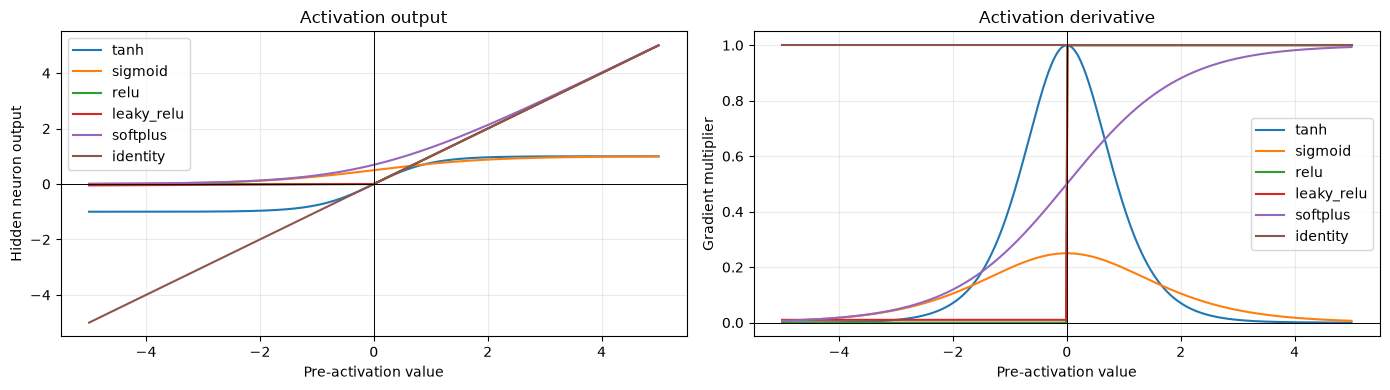

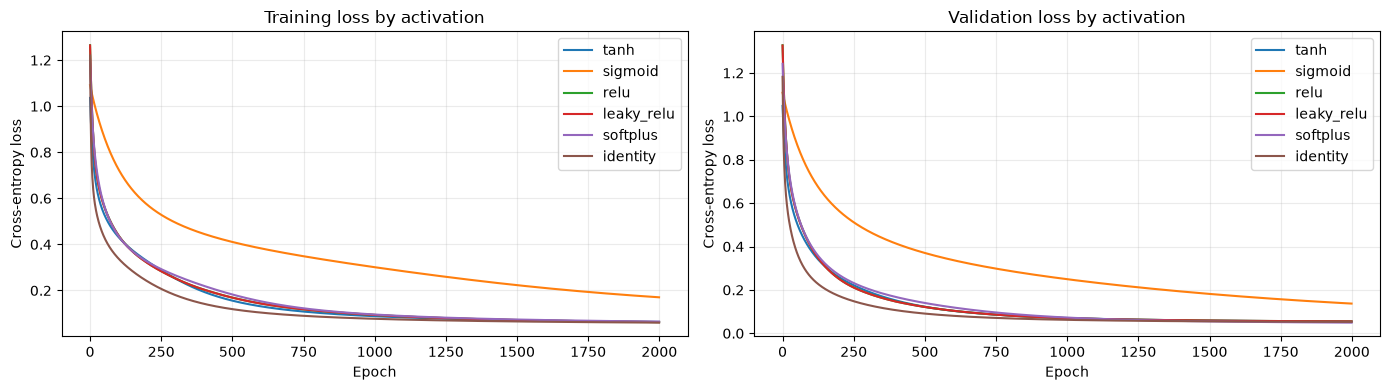

Activation | validation accuracy | test accuracy | final train loss | final validation loss
tanh         |               1.000 |          1.000 |           0.0634 |                0.0544
sigmoid      |               1.000 |          1.000 |           0.1704 |                0.1370
relu         |               1.000 |          1.000 |           0.0627 |                0.0549
leaky_relu   |               1.000 |          1.000 |           0.0627 |                0.0549
softplus     |               1.000 |          1.000 |           0.0648 |                0.0492
identity     |               1.000 |          1.000 |           0.0604 |                0.0526


In [29]:
# Biểu đồ 1: nhìn trực tiếp hình dạng activation và đạo hàm của chúng.
activation_input_values = np.linspace(-5, 5, 400)
figure, axes = plt.subplots(1, 2, figsize=(14, 4))

for activation_name in SUPPORTED_ACTIVATION_NAMES:
    activation_output_values = apply_hidden_activation(
        activation_input_values, activation_name
    )
    activation_derivative_values = hidden_activation_derivative(
        activation_input_values, activation_name
    )
    axes[0].plot(
        activation_input_values,
        activation_output_values,
        label=activation_name,
    )
    axes[1].plot(
        activation_input_values,
        activation_derivative_values,
        label=activation_name,
    )

axes[0].set_title('Activation output')
axes[0].set_xlabel('Pre-activation value')
axes[0].set_ylabel('Hidden neuron output')
axes[1].set_title('Activation derivative')
axes[1].set_xlabel('Pre-activation value')
axes[1].set_ylabel('Gradient multiplier')
for axis in axes:
    axis.axhline(0, color='black', linewidth=0.7)
    axis.axvline(0, color='black', linewidth=0.7)
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

# Biểu đồ 2: train một model riêng cho từng activation.
activation_models = {}
activation_comparison_rows = []

for activation_name in SUPPORTED_ACTIVATION_NAMES:
    comparison_model = SimpleANN(
        input_feature_count=4,
        hidden_neuron_count=8,
        output_class_count=3,
        learning_rate=0.05,
        random_seed=42,
        hidden_activation_name=activation_name,
    )
    comparison_model.fit(
        training_features,
        training_one_hot_labels,
        epochs=2000,
        validation_features=validation_features,
        validation_one_hot_targets=validation_one_hot_labels,
    )
    comparison_validation_accuracy = np.mean(
        comparison_model.predict(validation_features) == validation_labels
    )
    comparison_testing_accuracy = np.mean(
        comparison_model.predict(testing_features) == testing_labels
    )
    activation_models[activation_name] = comparison_model
    activation_comparison_rows.append(
        (
            activation_name,
            comparison_validation_accuracy,
            comparison_testing_accuracy,
            comparison_model.loss_history[-1],
            comparison_model.validation_loss_history[-1],
        )
    )

figure, axes = plt.subplots(1, 2, figsize=(14, 4))
for activation_name, comparison_model in activation_models.items():
    axes[0].plot(
        comparison_model.loss_history,
        label=activation_name,
    )
    axes[1].plot(
        comparison_model.validation_loss_history,
        label=activation_name,
    )
axes[0].set_title('Training loss by activation')
axes[1].set_title('Validation loss by activation')
for axis in axes:
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Cross-entropy loss')
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

print('Activation | validation accuracy | test accuracy | final train loss | final validation loss')
for row in activation_comparison_rows:
    print(f'{row[0]:<12} | {row[1]:>19.3f} | {row[2]:>14.3f} | {row[3]:>16.4f} | {row[4]:>21.4f}')

## 5. Kiểm tra kiến trúc mạng

Các shape này xác nhận đúng cấu trúc `4 -> 8 -> 3`.

In [30]:
# In shape để kiểm tra số connection giữa các layer.
# (4, 8): bốn input nối tới tám hidden neuron.
# (8, 3): tám hidden neuron nối tới ba output neuron.
print('Input -> hidden weights:', neural_network.input_to_hidden_weights.shape)
print('Hidden -> output weights:', neural_network.hidden_to_output_weights.shape)
print('Hidden biases:', neural_network.hidden_layer_biases.shape)
print('Output biases:', neural_network.output_layer_biases.shape)

assert neural_network.input_to_hidden_weights.shape == (4, 8)
assert neural_network.hidden_to_output_weights.shape == (8, 3)
assert neural_network.hidden_layer_biases.shape == (1, 8)
assert neural_network.output_layer_biases.shape == (1, 3)

Input -> hidden weights: (4, 8)
Hidden -> output weights: (8, 3)
Hidden biases: (1, 8)
Output biases: (1, 3)


## 6. Trace input/output của từng layer

Ta chọn một mẫu test và hiển thị dữ liệu ở từng chặng:

```text
raw input (1, 4)
    -> normalized input (1, 4)
    -> hidden output (1, 8)
    -> output probabilities (1, 3)
    -> predicted species
```

Trace dùng một mẫu có batch dimension `(1, 4)`. Vì giữ batch dimension, các phép nhân ma trận vẫn giống hệt khi chạy nhiều mẫu; chỉ thay `n` bằng `1`.

In [31]:
# Chọn một mẫu test để quan sát toàn bộ forward pass bằng mắt.
sample_index = 0
# Giữ raw input để hiển thị đúng đơn vị cm trong Iris dataset.
raw_sample_features = testing_features_raw[sample_index:sample_index + 1]
# Model nhận input đã chuẩn hóa, không nhận trực tiếp số đo raw.
sample_features = (
    raw_sample_features - training_feature_means
) / training_feature_stds
# trace() trả về input, hidden output, output logits và probabilities.
forward_pass_trace = neural_network.trace(sample_features)

print('Raw input:', raw_sample_features)
print('Raw input shape:', raw_sample_features.shape)
print('Hidden layer input:', forward_pass_trace['input'])
print('Hidden layer input shape:', forward_pass_trace['input'].shape)
print('Hidden layer output:', forward_pass_trace['hidden_output'])
print('Hidden layer output shape:', forward_pass_trace['hidden_output'].shape)
print('Output layer input:', forward_pass_trace['hidden_output'])
print('Output layer output:', forward_pass_trace['output_probabilities'])
print('Output layer output shape:', forward_pass_trace['output_probabilities'].shape)

predicted_class_index = forward_pass_trace['output_probabilities'].argmax()
actual_class_index = testing_labels[sample_index]
print('Actual species:', iris_dataset.target_names[actual_class_index])
print('Predicted species:', iris_dataset.target_names[predicted_class_index])

# Kiểm tra ba xác suất output tạo thành một phân phối xác suất hợp lệ.
assert np.isclose(forward_pass_trace['output_probabilities'].sum(), 1.0)

Raw input: [[6.1 3.  4.6 1.4]]
Raw input shape: (1, 4)
Hidden layer input: [[ 0.228 -0.232  0.442  0.251]]
Hidden layer input shape: (1, 4)
Hidden layer output: [[-0.544  0.183  0.643 -0.331 -0.291 -0.548  0.95   0.197]]
Hidden layer output shape: (1, 8)
Output layer input: [[-0.544  0.183  0.643 -0.331 -0.291 -0.548  0.95   0.197]]
Output layer output: [[0.003 0.984 0.013]]
Output layer output shape: (1, 3)
Actual species: versicolor
Predicted species: versicolor


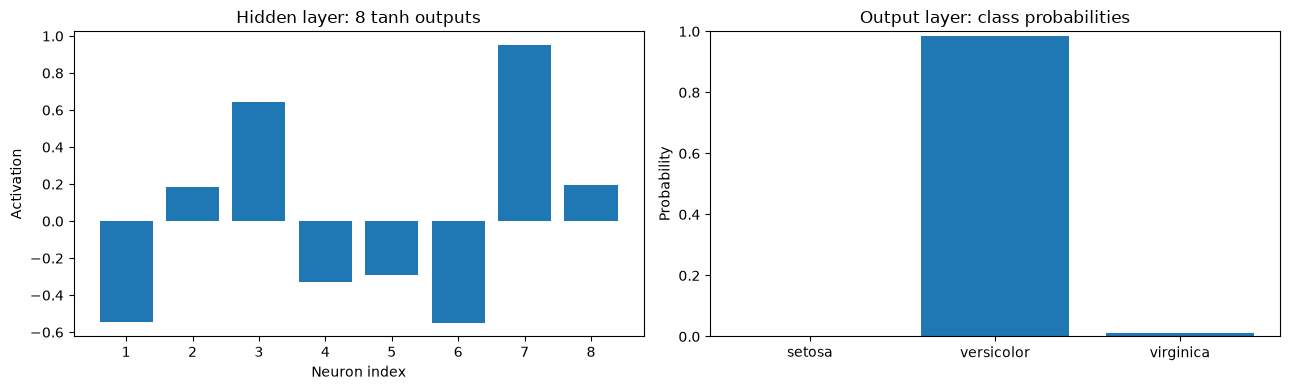

In [32]:
# Biểu đồ trái cho thấy 8 activation hidden; biểu đồ phải cho thấy 3 xác suất.
figure, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mỗi cột là output của một neuron trong hidden layer.
hidden_layer_outputs = forward_pass_trace['hidden_output'][0]
axes[0].bar(np.arange(1, 9), hidden_layer_outputs)
axes[0].set_title(f'Hidden layer: 8 {neural_network.hidden_activation_name} outputs')
axes[0].set_xlabel('Neuron index')
axes[0].set_ylabel('Activation')

# Ba cột cuối cùng là xác suất của ba loài hoa.
output_class_probabilities = forward_pass_trace['output_probabilities'][0]
axes[1].bar(iris_dataset.target_names, output_class_probabilities)
axes[1].set_title('Output layer: class probabilities')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 7. Chạy thử nhiều mẫu

Mỗi dòng cho biết nhãn thật, nhãn dự đoán và xác suất của cả ba lớp.

In [33]:
# Lấy đều năm vị trí trong test set để xem nhiều trường hợp khác nhau.
sample_indices = np.linspace(0, len(testing_features) - 1, 5, dtype=int)

for sample_index in sample_indices:
    raw_sample_features = testing_features_raw[sample_index:sample_index + 1]
    sample_features = (
        raw_sample_features - training_feature_means
    ) / training_feature_stds
    # predict_proba trả về ma trận (1, 3); [0] lấy hàng của mẫu hiện tại.
    sample_probabilities = neural_network.predict_proba(sample_features)[0]
    predicted_class_index = sample_probabilities.argmax()
    actual_class_index = testing_labels[sample_index]

    print(f'Sample {sample_index}')
    print('  Input:', raw_sample_features[0])
    print('  Actual:', iris_dataset.target_names[actual_class_index])
    print('  Predicted:', iris_dataset.target_names[predicted_class_index])
    readable_probabilities = dict(zip(iris_dataset.target_names.tolist(), sample_probabilities.round(3).tolist()))
    print('  Probabilities:', readable_probabilities)
    print()

Sample 0
  Input: [6.1 3.  4.6 1.4]
  Actual: versicolor
  Predicted: versicolor
  Probabilities: {'setosa': 0.003, 'versicolor': 0.984, 'virginica': 0.013}

Sample 7
  Input: [4.3 3.  1.1 0.1]
  Actual: setosa
  Predicted: setosa
  Probabilities: {'setosa': 0.994, 'versicolor': 0.006, 'virginica': 0.0}

Sample 14
  Input: [5.8 2.7 4.1 1. ]
  Actual: versicolor
  Predicted: versicolor
  Probabilities: {'setosa': 0.004, 'versicolor': 0.995, 'virginica': 0.001}

Sample 21
  Input: [6.  2.2 4.  1. ]
  Actual: versicolor
  Predicted: versicolor
  Probabilities: {'setosa': 0.001, 'versicolor': 0.998, 'virginica': 0.001}

Sample 29
  Input: [5.7 2.5 5.  2. ]
  Actual: virginica
  Predicted: virginica
  Probabilities: {'setosa': 0.0, 'versicolor': 0.014, 'virginica': 0.986}



## 8. Đánh giá model

Validation giúp theo dõi model trong quá trình phát triển; test chỉ được dùng ở cuối để ước lượng kết quả trên dữ liệu mới. Loss curve cho thấy quá trình học, còn confusion matrix cho thấy model nhầm lớp nào với lớp nào.

Nếu training loss giảm nhưng validation loss tăng, đó là dấu hiệu model đang học quá sát training set (overfitting). Với Iris nhỏ và đơn giản, demo này thường cho kết quả tốt trên cả hai tập.

Validation accuracy: 1.000
Test accuracy: 1.000
Initial loss: 1.0360
Final training loss: 0.0634
Final validation loss: 0.0544


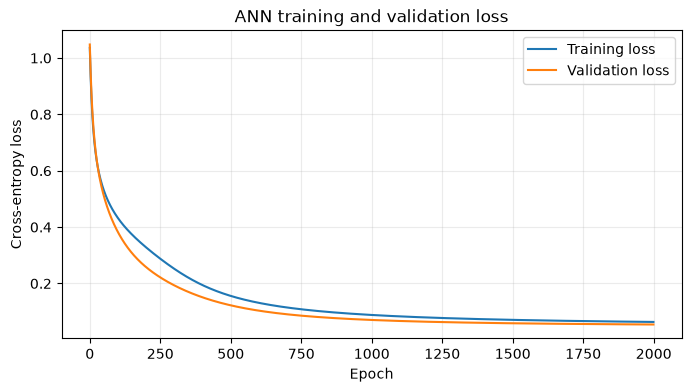

In [34]:
print(f'Validation accuracy: {validation_accuracy:.3f}')
print(f'Test accuracy: {testing_accuracy:.3f}')
print(f'Initial loss: {neural_network.loss_history[0]:.4f}')
print(f'Final training loss: {neural_network.loss_history[-1]:.4f}')
print(f'Final validation loss: {neural_network.validation_loss_history[-1]:.4f}')

assert neural_network.loss_history[-1] < neural_network.loss_history[0]
assert np.allclose(
    neural_network.predict_proba(validation_features).sum(axis=1),
    1.0,
    atol=1e-6,
)
assert np.allclose(
    neural_network.predict_proba(testing_features).sum(axis=1),
    1.0,
    atol=1e-6,
)

figure, axis = plt.subplots(figsize=(8, 4))
axis.plot(neural_network.loss_history, label='Training loss')
axis.plot(neural_network.validation_loss_history, label='Validation loss')
axis.set_title('ANN training and validation loss')
axis.set_xlabel('Epoch')
axis.set_ylabel('Cross-entropy loss')
axis.legend()
axis.grid(alpha=0.25)
plt.show()

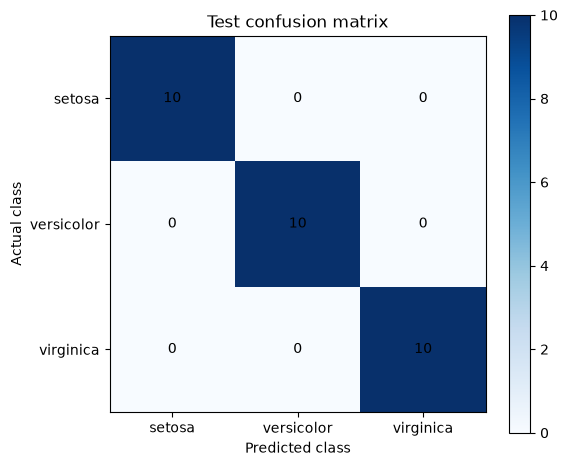

In [35]:
# Hàng là lớp thật, cột là lớp model dự đoán.
# Mỗi lần gặp một cặp (actual, predicted), tăng ô tương ứng lên 1.
confusion_matrix = np.zeros((3, 3), dtype=int)
for actual_class_index, predicted_class_index in zip(
    testing_labels, testing_predictions
):
    confusion_matrix[actual_class_index, predicted_class_index] += 1

figure, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(confusion_matrix, cmap='Blues')
axis.set_xticks(range(3), iris_dataset.target_names)
axis.set_yticks(range(3), iris_dataset.target_names)
axis.set_xlabel('Predicted class')
axis.set_ylabel('Actual class')
axis.set_title('Test confusion matrix')
figure.colorbar(image, ax=axis)

for actual_class_index in range(3):
    for predicted_class_index in range(3):
        axis.text(
            predicted_class_index,
            actual_class_index,
            confusion_matrix[actual_class_index, predicted_class_index],
            ha='center',
            va='center',
        )

plt.tight_layout()
plt.show()

## Kết luận

Model đã đi qua đầy đủ chu trình:

```text
input -> hidden layer -> output layer -> loss -> backpropagation -> update weights
```

Notebook dùng dataset nhỏ để làm rõ cơ chế ANN. Kết quả accuracy không nên được hiểu là bằng chứng rằng mạng tự viết luôn tốt hơn mọi model khác.